In [29]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

conn = sqlite3.connect('Formula1.sqlite')
curr = conn.cursor()

In [30]:
# Execute the query
# (This is a special query for finding the table names. You don't need to memorize it.)
curr.execute("""SELECT name FROM sqlite_master WHERE type = 'table';""")
# Fetch the result and store it in table_names
table_names = curr.fetchall()
table_names

[('circuits',),
 ('races',),
 ('driver_standings',),
 ('drivers',),
 ('constructors',),
 ('results',),
 ('constructor_standings',),
 ('constructor_results',),
 ('laptimes',),
 ('pitstops',),
 ('qualifying',),
 ('seasons',),
 ('status',)]

In [31]:
pd.DataFrame(
    data=curr.execute("""SELECT * FROM races;""").fetchall(),
    columns=[x[0] for x in curr.description]
).head()

,raceId,year,round,circuitId,name,date,time,url
0,1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...
1,2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...
2,3,2009,3,17,Chinese Grand Prix,2009-04-19,07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...
3,4,2009,4,3,Bahrain Grand Prix,2009-04-26,12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...
4,5,2009,5,4,Spanish Grand Prix,2009-05-10,12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...


# Data Visualisation

C:\Users\HP PROBOOK 11X360G6\AppData\Local\Temp\ipykernel_3360\2189980200.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(


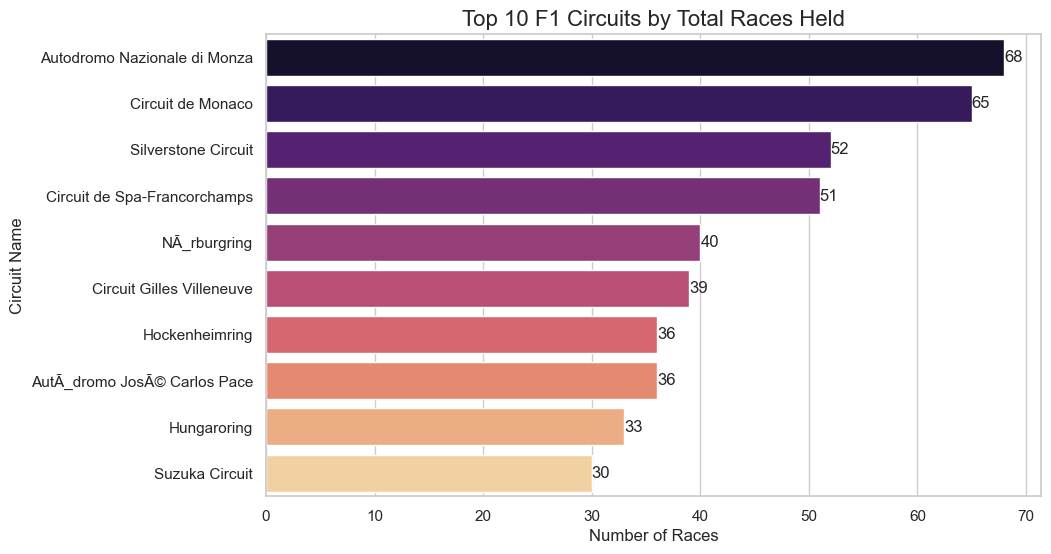

In [32]:
query = ("""SELECT 
        circuits.name, 
        COUNT(races.raceId) AS total_races
    FROM circuits
    JOIN races ON circuits.circuitId = races.circuitId
    GROUP BY circuits.name
    ORDER BY total_races DESC
    LIMIT 10 ;""")

df_plot = pd.DataFrame(
    data=curr.execute(query).fetchall(),
    columns=[x[0] for x in curr.description]
)

# 2. Set the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 3. Create the bar plot
plot = sns.barplot(
    data=df_plot, 
    x='total_races', 
    y='name', 
    palette='magma'
)

# 4. Add labels and title
plt.title('Top 10 F1 Circuits by Total Races Held', fontsize=16)
plt.xlabel('Number of Races', fontsize=12)
plt.ylabel('Circuit Name', fontsize=12)

# Optional: Add the actual numbers at the end of each bar
for i in plot.containers:
    plot.bar_label(i,)

plt.show()


C:\Users\HP PROBOOK 11X360G6\AppData\Local\Temp\ipykernel_3360\2649682726.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(


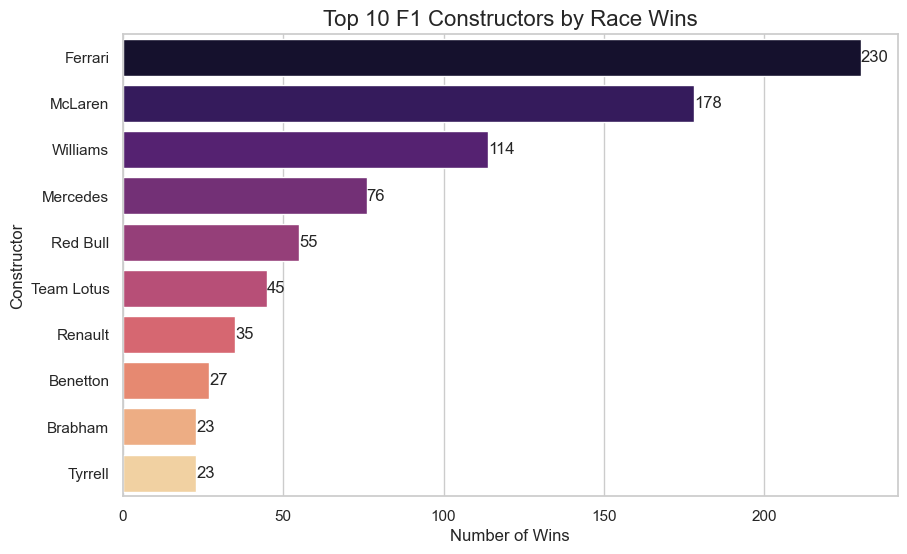

In [33]:
query = """
    SELECT 
        constructors.name AS constructor_name,
        COUNT(results.resultId) AS total_wins
    FROM constructors
    JOIN results ON constructors.constructorId = results.constructorId
    WHERE results.position = '1'
    GROUP BY constructors.constructorId
    ORDER BY total_wins DESC
    LIMIT 10;
"""

df_constructors = pd.DataFrame(
    data=curr.execute(query).fetchall(),
    columns=[x[0] for x in curr.description]
)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

plot = sns.barplot(
    data=df_constructors,
    x='total_wins',
    y='constructor_name',
    palette='magma'
)

plt.title('Top 10 F1 Constructors by Race Wins', fontsize=16)
plt.xlabel('Number of Wins', fontsize=12)
plt.ylabel('Constructor', fontsize=12)

for i in plot.containers:
    plot.bar_label(i)

plt.show()

C:\Users\HP PROBOOK 11X360G6\AppData\Local\Temp\ipykernel_3360\1670071109.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(


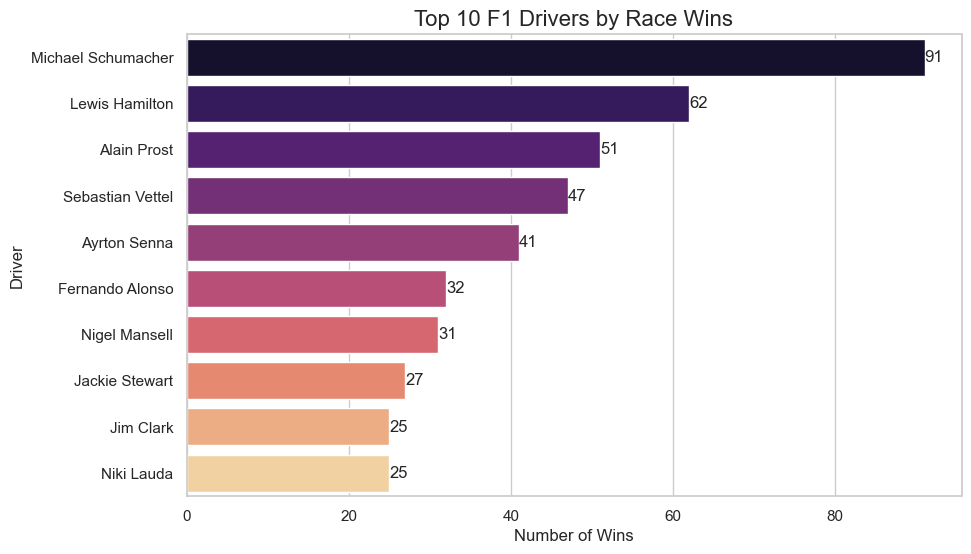

In [34]:
query = """
    SELECT 
        drivers.forename || ' ' || drivers.surname AS driver_name,
        COUNT(results.resultId) AS total_wins
    FROM drivers
    JOIN results ON drivers.driverId = results.driverId
    WHERE results.position = '1'
    GROUP BY drivers.driverId
    ORDER BY total_wins DESC
    LIMIT 10;
"""

df_drivers = pd.DataFrame(
    data=curr.execute(query).fetchall(),
    columns=[x[0] for x in curr.description]
)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

plot = sns.barplot(
    data=df_drivers,
    x='total_wins',
    y='driver_name',
    palette='magma'
)

plt.title('Top 10 F1 Drivers by Race Wins', fontsize=16)
plt.xlabel('Number of Wins', fontsize=12)
plt.ylabel('Driver', fontsize=12)

for i in plot.containers:
    plot.bar_label(i)

plt.show()

C:\Users\HP PROBOOK 11X360G6\AppData\Local\Temp\ipykernel_3360\2649682726.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(


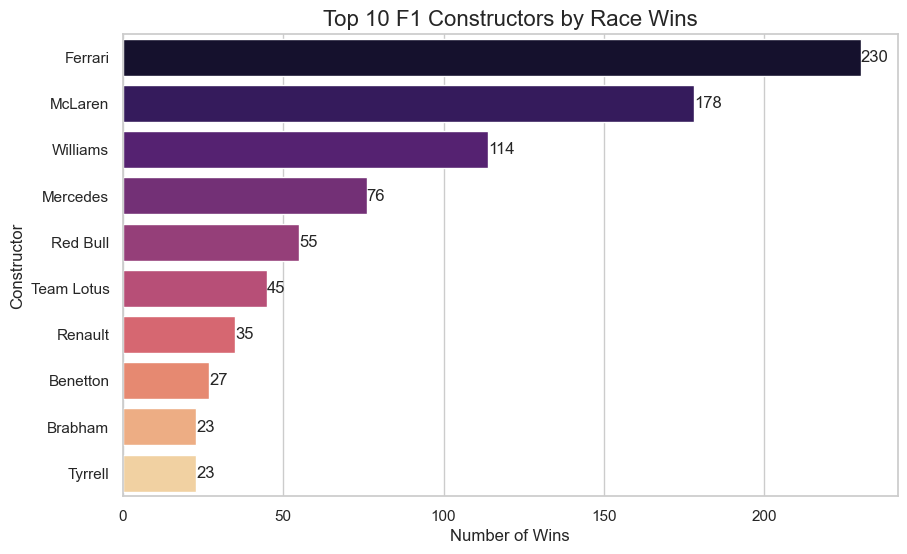

In [35]:
query = """
    SELECT 
        constructors.name AS constructor_name,
        COUNT(results.resultId) AS total_wins
    FROM constructors
    JOIN results ON constructors.constructorId = results.constructorId
    WHERE results.position = '1'
    GROUP BY constructors.constructorId
    ORDER BY total_wins DESC
    LIMIT 10;
"""

df_constructors = pd.DataFrame(
    data=curr.execute(query).fetchall(),
    columns=[x[0] for x in curr.description]
)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

plot = sns.barplot(
    data=df_constructors,
    x='total_wins',
    y='constructor_name',
    palette='magma'
)

plt.title('Top 10 F1 Constructors by Race Wins', fontsize=16)
plt.xlabel('Number of Wins', fontsize=12)
plt.ylabel('Constructor', fontsize=12)

for i in plot.containers:
    plot.bar_label(i)

plt.show()

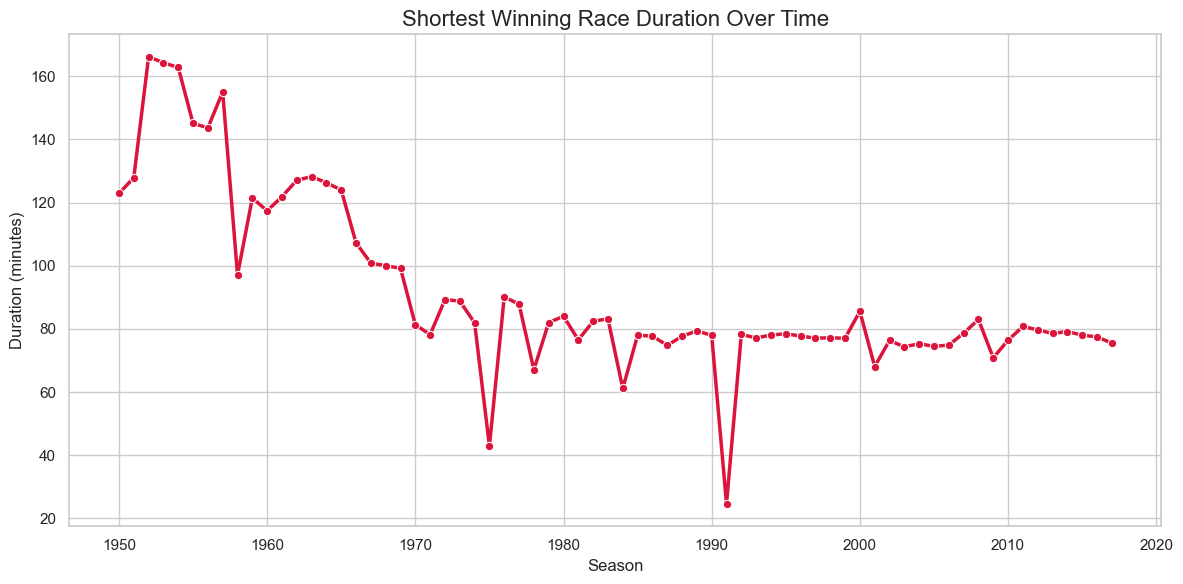

In [36]:
query = """
    SELECT 
        races.year,
        races.name AS race_name,
        MIN(results.milliseconds) / 60000.0 AS duration_minutes
    FROM results
    JOIN races ON results.raceId = races.raceId
    WHERE results.position = '1'
      AND results.milliseconds IS NOT NULL
      AND results.milliseconds != '\\N'
    GROUP BY races.year
    ORDER BY races.year ASC;
"""

df_races = pd.DataFrame(
    data=curr.execute(query).fetchall(),
    columns=[x[0] for x in curr.description]
)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df_races,
    x='year',
    y='duration_minutes',
    marker='o',
    color='crimson',
    linewidth=2.5
)

plt.title('Shortest Winning Race Duration Over Time', fontsize=16)
plt.xlabel('Season', fontsize=12)
plt.ylabel('Duration (minutes)', fontsize=12)

plt.tight_layout()
plt.show()